# Volatility Analysis: SP500 vs BTC

Objective:
Study stylized facts of financial markets using log returns.

Key analyses:
- Return distributions
- Volatility clustering
- Autocorrelation
- Comparative volatility behaviour

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 — Load Processed Data

In [2]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

sp500.head()

,Open,High,Low,Close,Volume,log_return,vol_30
Date,,,,,,,
2014-01-03,149.238532,149.539900,148.749847,148.961609,81390600,-0.000164,NaN
2014-01-06,149.450282,149.507290,148.301852,148.529907,108028200,-0.002902,NaN
2014-01-07,149.124474,149.694612,149.010446,149.442123,86144200,0.006123,NaN
2014-01-08,149.417742,149.727251,148.961631,149.474762,96582300,0.000218,NaN
2014-01-09,149.955259,149.971552,148.888282,149.572449,90683400,0.000653,NaN


## Step 3 — Return Distribution Comparison

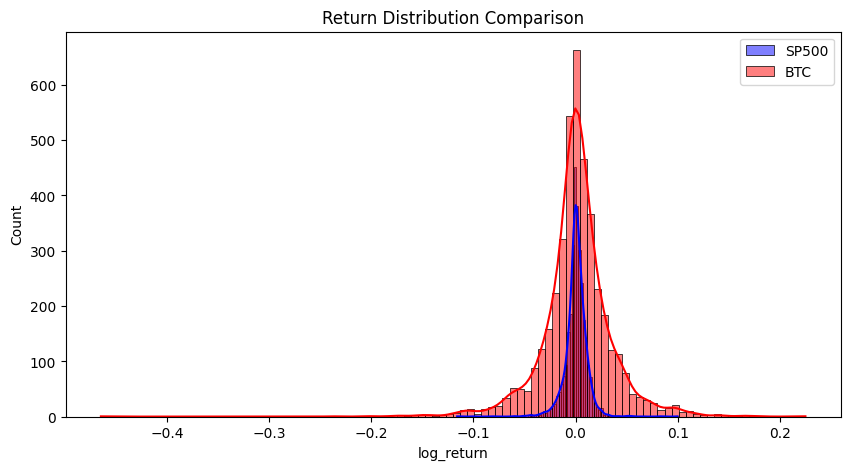

In [3]:
plt.figure(figsize=(10,5))
sns.histplot(sp500["log_return"], bins=100, color="blue", label="SP500", kde=True)
sns.histplot(btc["log_return"], bins=100, color="red", label="BTC", kde=True)

plt.legend()
plt.title("Return Distribution Comparison")
plt.show()

## Step 4 — Rolling Volatility Comparison

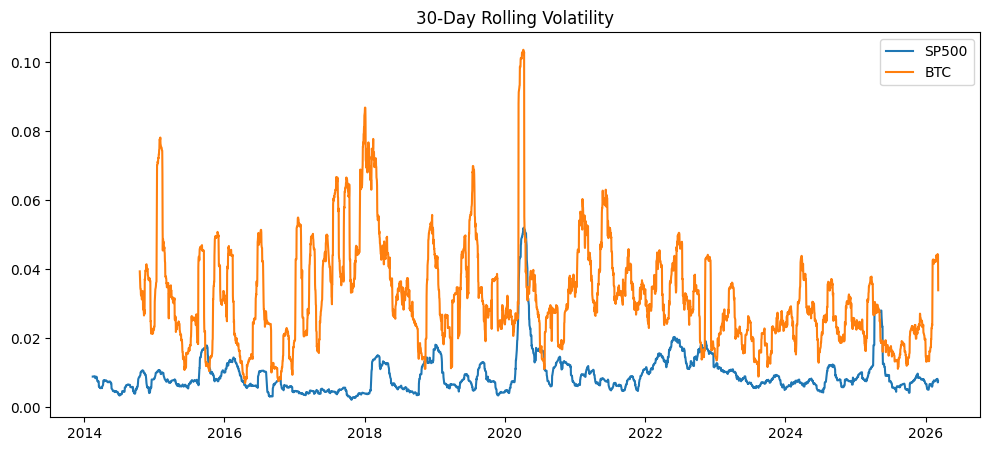

In [4]:
plt.figure(figsize=(12,5))

plt.plot(sp500["vol_30"], label="SP500")
plt.plot(btc["vol_30"], label="BTC")

plt.legend()
plt.title("30-Day Rolling Volatility")
plt.show()

## Step 5 — Volatility Clustering

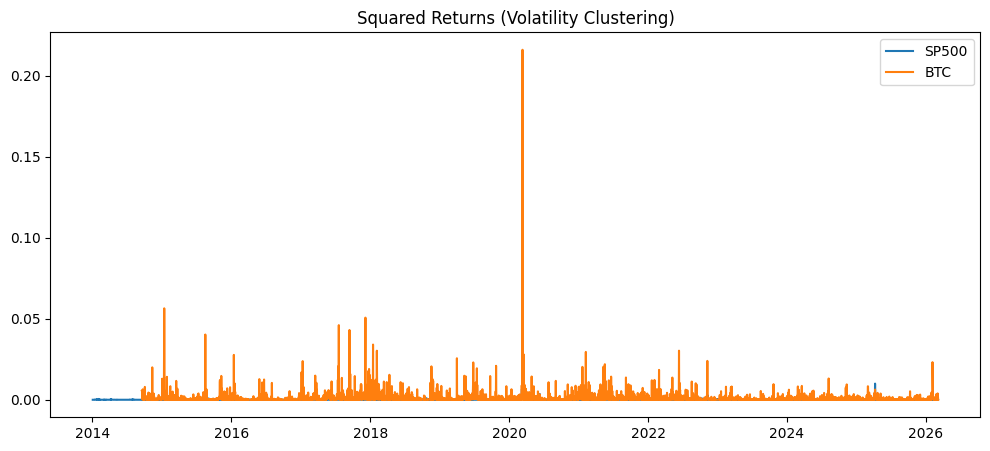

In [5]:
plt.figure(figsize=(12,5))

plt.plot(sp500["log_return"]**2, label="SP500")
plt.plot(btc["log_return"]**2, label="BTC")

plt.legend()
plt.title("Squared Returns (Volatility Clustering)")
plt.show()

## Step 6 — Autocorrelation of Returns

In [7]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------- ----------- 6.8/9.5 MB 34.3 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 30.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -----

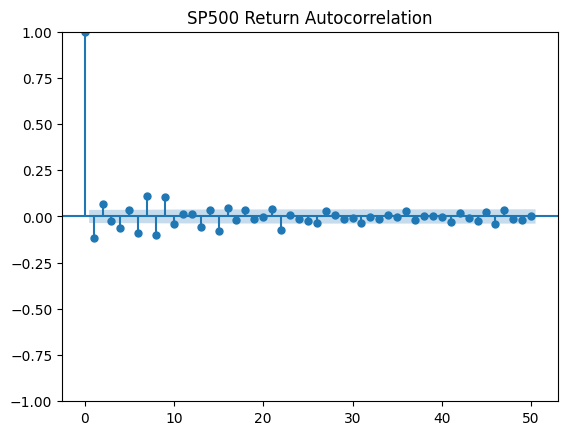

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(sp500["log_return"], lags=50)
plt.title("SP500 Return Autocorrelation")
plt.show()

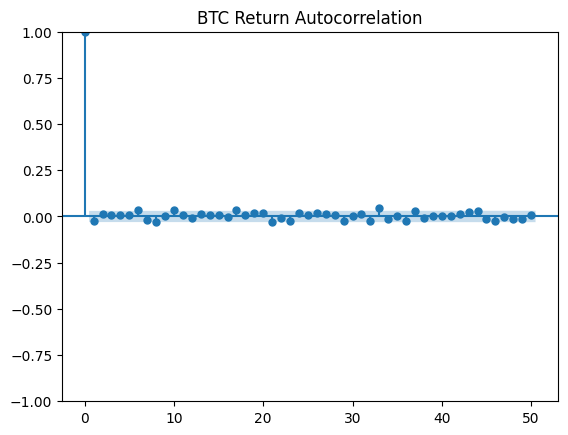

In [9]:
plot_acf(btc["log_return"], lags=50)
plt.title("BTC Return Autocorrelation")
plt.show()